# Tidy Data Project: Olympics Dataset
## Author: Natalie Astoquilca-May
## Date: 3.20.26

In [108]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/Users/natalie/Documents/ASTOQUILCA-MAY-Data-Science-Portfolio/TidyData-Project/olympics_08_medalists.csv")

## Initial Exploration

In [109]:
print(df.head())

       medalist_name male_archery female_archery male_athletics  \
0    Aaron Armstrong          NaN            NaN           gold   
1      Aaron Peirsol          NaN            NaN            NaN   
2   Abdullo Tangriev          NaN            NaN            NaN   
3  Abeer Abdelrahman          NaN            NaN            NaN   
4            Abhinav          NaN            NaN            NaN   

  female_athletics male_badminton female_badminton male_baseball  \
0              NaN            NaN              NaN           NaN   
1              NaN            NaN              NaN           NaN   
2              NaN            NaN              NaN           NaN   
3              NaN            NaN              NaN           NaN   
4              NaN            NaN              NaN           NaN   

  male_basketball female_basketball  ... female_beach volleyball  \
0             NaN               NaN  ...                     NaN   
1             NaN               NaN  ...            

In [110]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1875 entries, 0 to 1874
Data columns (total 71 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   medalist_name                 1875 non-null   object
 1   male_archery                  11 non-null     object
 2   female_archery                9 non-null      object
 3   male_athletics                85 non-null     object
 4   female_athletics              81 non-null     object
 5   male_badminton                12 non-null     object
 6   female_badminton              10 non-null     object
 7   male_baseball                 72 non-null     object
 8   male_basketball               35 non-null     object
 9   female_basketball             36 non-null     object
 10  male_boxing                   44 non-null     object
 11  male_canoeing and kayaking    53 non-null     object
 12  female_canoeing and kayaking  21 non-null     object
 13  male_road bicycle 

In [111]:
print(df.describe())

          medalist_name male_archery female_archery male_athletics  \
count              1875           11              9             85   
unique             1875            3              3              3   
top     Aaron Armstrong       bronze         bronze         silver   
freq                  1            4              4             31   

       female_athletics male_badminton female_badminton male_baseball  \
count                81             12               10            72   
unique                3              3                3             3   
top              silver         silver           silver        silver   
freq                 28              4                4            24   

       male_basketball female_basketball  ... female_beach volleyball  \
count               35                36  ...                       6   
unique               3                 3  ...                       3   
top             bronze            bronze  ...                   

Observations: 
- 71 columns -- the first one is medalist_name and the rest are sports
- 1875 medalists
- 70/2 = 35 sport
- each sport has a male and female column. I can start by melting these into one.
- most of these cells are empty, because each athlete is listed for every sport 
- I will use `pd.melt()` to convert this wide data into a long, tidy format where each row represents a single observation

## Cleaning and Tidying Data

Clean data helps ensure that our visualizations are as accurate, consistent, and complete as possible. An inmportant step in data cleaning is data tidying, which is described as "structuring datasets to facilitate manipulation, visualisation and modelling" (Wickham)

In [112]:
# Cleaning and tidying data

# Melt the dataset
sport_columns = df.columns[1:] #this grabs every column except the first one, which is medalist_name.
#all other columns are sports, and I want to melt them into a single column.

df_melted = df.melt(
        id_vars = ["medalist_name"],
        value_vars = sport_columns,
        var_name = "sex_sport", 
        value_name="medal"
        )
print(df_melted.head())


       medalist_name     sex_sport medal
0    Aaron Armstrong  male_archery   NaN
1      Aaron Peirsol  male_archery   NaN
2   Abdullo Tangriev  male_archery   NaN
3  Abeer Abdelrahman  male_archery   NaN
4            Abhinav  male_archery   NaN


In [113]:
# now, I want to remove the NaN values from the 'medal' column
df_melted = df_melted.dropna(subset = ["medal"])
print(df_melted.head())

      medalist_name     sex_sport   medal
177    Bair Badënov  male_archery  bronze
676   Ilario Di Buò  male_archery  silver
682    Im Dong-hyun  male_archery    gold
760       Jiang Lin  male_archery  bronze
920  Lee Chang-hwan  male_archery    gold


In [114]:
# I also want sex in a separate column, so I will use splitting.
df_melted[["sex", "sport"]] = df_melted["sex_sport"].str.split("_", n=1, expand=True)
print(df_melted.head())

      medalist_name     sex_sport   medal   sex    sport
177    Bair Badënov  male_archery  bronze  male  archery
676   Ilario Di Buò  male_archery  silver  male  archery
682    Im Dong-hyun  male_archery    gold  male  archery
760       Jiang Lin  male_archery  bronze  male  archery
920  Lee Chang-hwan  male_archery    gold  male  archery


In [115]:
#now, I can drop the sex_sport column, since I have the information in separate columns.
df_clean = df_melted.drop(columns = ["sex_sport"])
print(df_clean.head())

      medalist_name   medal   sex    sport
177    Bair Badënov  bronze  male  archery
676   Ilario Di Buò  silver  male  archery
682    Im Dong-hyun    gold  male  archery
760       Jiang Lin  bronze  male  archery
920  Lee Chang-hwan    gold  male  archery


Now:
- Each variable is in its own column.
- Each observation forms its own row.
- we can move forward to visualizing the data!

## Visualizations

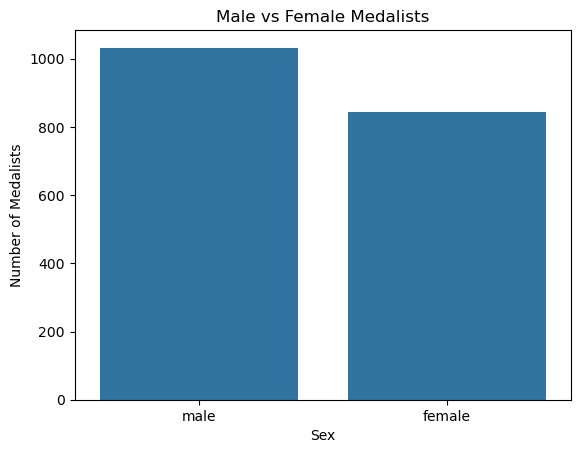

In [116]:
# Number of medalists by sex: count plot
sns.countplot(data=df_clean, x="sex")
plt.title("Male vs Female Medalists")
plt.xlabel("Sex")
plt.ylabel("Number of Medalists")
plt.show()

In [117]:
# pivot table of the same data to get the exact counts. This is also a good way to check that the countplot is correct.
pivot_sex = df_clean.pivot_table(
    index = "sex",
    values = "medalist_name",
    aggfunc = "count"
)
print(pivot_sex)

        medalist_name
sex                  
female            843
male             1032


Overall, there were 199 more male medalists than female medalists from the 2008 Olympics.

Text(0, 0.5, 'Sport')

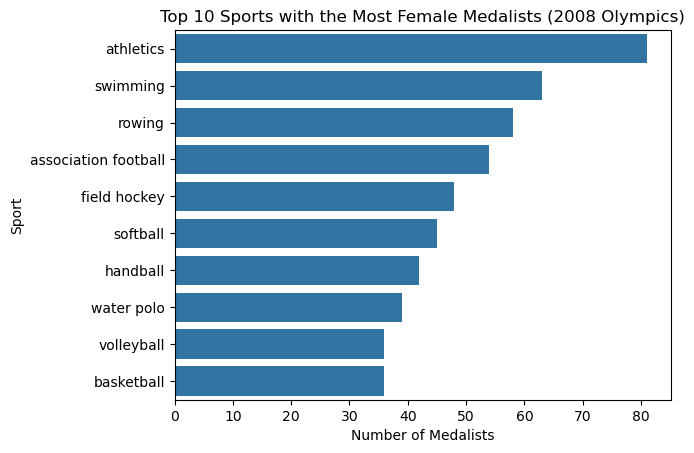

In [118]:
#building off of the countplot, I want to see which sports had the most female medalists. 

female_medalists = df_clean[df_clean["sex"] == "female"] #filtering by only female athletes
top10_female_sports = female_medalists['sport'].value_counts().head(10).index #pulling the top 10 sports with the most female medalists
# building the visualization
sns.countplot(
    data = female_medalists, 
    y = "sport", 
    order=top10_female_sports
)
plt.title("Top 10 Sports with the Most Female Medalists (2008 Olympics)")
plt.xlabel("Number of Medalists")
plt.ylabel("Sport")

"Athletics" had the most female medalists (~80). According to Google, this category includeded track and field, road running, and racewalking. 
